In [90]:
import pandas as pd
from tbparse import SummaryReader

# ==========================================
# ZELLE 1: KONFIGURATION & DATEN LADEN
# ==========================================
LOG_DIR = "logs/locked_c"  # <-- Hauptordner anpassen

print(f"Lade alle Runs aus dem Ordner '{LOG_DIR}'...")

# Extrahiert die Daten und behält die Run-Namen als 'dir_name'
reader = SummaryReader(LOG_DIR, extra_columns={'dir_name'})
df_all_runs = reader.scalars

# Kontrollausgabe

irrelevant_runs = ["_run_5", "_run_6", "_run_7", "_run_8", "_run_9"]
for run in irrelevant_runs:
    df_all_runs = df_all_runs[df_all_runs["dir_name"] != run]
runs_found = df_all_runs['dir_name'].unique()
print(f"Fertig! Gefundene Runs: {len(runs_found)}")
for run in runs_found:
    print(f" - {run}")

Lade alle Runs aus dem Ordner 'logs/locked_c'...


Fertig! Gefundene Runs: 5
 - _run_0
 - _run_1
 - _run_2
 - _run_3
 - _run_4


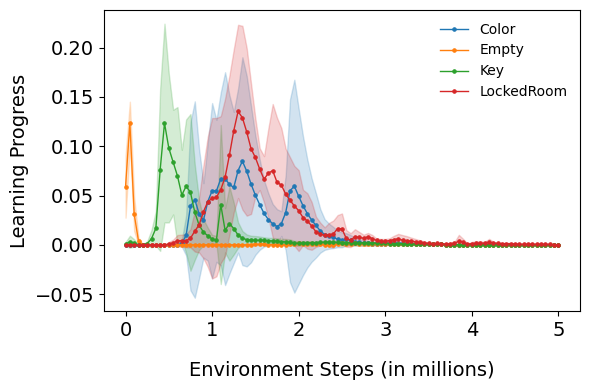

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ==========================================
# ZELLE 2: AGGREGIERTER MITTELWERT-PLOT (ALLE RUNS)
# ==========================================
# 1. Konfiguration
SAVE_PATH = "pictures/plots/locked/Teacher_LP.jpg"
"SR"
"Selected"
"Teacher_LP"
"baseline"
METRIC_KEYWORD = "Teacher_LP"
"# Selected"
"Success ratio %"
"Teacher_LP"
Y_AXIS_LABEL = "Learning Progress" 
"# Selected" 
"Success ratio" 
"Learning Progress" 

STEP_BUCKET_SIZE = 50000

NORMALIZE = False
ENFORCE_BOUNDS = NORMALIZE  
Y_MIN = -5
Y_MAX = 105

TASK_MAPPING = {
    "color": "Color",
    "empty": "Empty",
    "key": "Key",
    "locked_room": "LockedRoom"
}


TASK_COLORS = {
    "Color": "tab:blue",
    "Empty": "tab:orange",
    "Key": "tab:green",
    "LockedRoom": "tab:red" 
}

# 2. Daten filtern & umbenennen (Das bleibt, weil es saubere Vorarbeit ist)
df_metrics = df_all_runs[df_all_runs['tag'].str.contains(METRIC_KEYWORD)].copy()
df_metrics['Task'] = df_metrics['tag'].apply(lambda x: x.split('/')[-1] if '/' in x else x)
df_metrics['Task'] = df_metrics['Task'].replace(TASK_MAPPING)

if NORMALIZE:
    df_metrics['value'] = df_metrics['value'] * 100

# 3. DIE AUFGERÄUMTE DATENVERARBEITUNG
# Wir werfen die Schritte in "Eimer" (Buckets) und mitteln sie direkt. 
# Das glättet die Kurve UND macht sie für Seaborn lesbar in nur 2 Zeilen.
df_metrics['step'] = (df_metrics['step'] // STEP_BUCKET_SIZE) * STEP_BUCKET_SIZE
df_clean = df_metrics.groupby(['Task', 'dir_name', 'step'], as_index=False)['value'].mean()

# 4. Plotten
plt.figure(figsize=(6, 4)) 
sns.lineplot(
    data=df_clean, 
    x='step', 
    y='value', 
    hue='Task', 
    palette=TASK_COLORS, # <--- NEU: Zwingt Seaborn, exakt diese Farben zu nutzen!
    estimator='mean',  
    errorbar='sd',     
    linewidth=1,
    marker='o',        
    markersize=2.5,      
    markeredgecolor=None 
)

# 5. Styling
plt.xlabel("Environment Steps (in millions)", fontsize=14, labelpad=15)
plt.ylabel(f"{Y_AXIS_LABEL} (%)" if NORMALIZE else Y_AXIS_LABEL, fontsize=14)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1e6:g}'))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

if ENFORCE_BOUNDS:
    plt.ylim(Y_MIN, Y_MAX)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(SAVE_PATH, format="jpg", bbox_inches="tight")
plt.show()

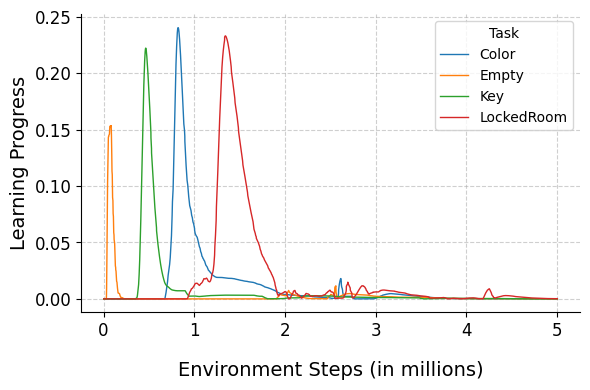

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ==========================================
# ZELLE 2: MULTI-METRIK PLOT FÜR EINEN RUN
# ==========================================
# 1. Konfiguration
REPRESENTATIVE_RUN = "_run_0" 
SAVE_PATH = "pictures/plots/locked/Teacher_LP.png"
"pictures/plots/locked/Selected.png"
"pictures/plots/locked/Teacher_LP.png"
"pictures/plots/locked/SR.png"
"pictures/plots/locked/baseline.png"

METRIC_KEYWORD = "Teacher_LP"
"# Selected"
"Success ratio %"
"Teacher_LP"
Y_AXIS_LABEL = "Learning Progress"
"# Selected" 
"Success ratio" 
"Learning Progress" 
# Glättung
SMOOTHING_WINDOW = 10

# Steuerung der Normalisierung (Mal 100 rechnen)
NORMALIZE = False  
ENFORCE_BOUNDS = False  
Y_MIN = -5
Y_MAX = 105


TASK_MAPPING = {
    "color": "Color",
    "empty": "Empty",
    "key": "Key",
    "locked_room": "LockedRoom"
}

# ==========================================
# DATENVERARBEITUNG
# ==========================================
# A) Nur den ausgewählten Run behalten
df_run = df_all_runs[df_all_runs['dir_name'].str.contains(REPRESENTATIVE_RUN)].copy()

# B) Nur die relevanten Metriken behalten
df_metrics = df_run[df_run['tag'].str.contains(METRIC_KEYWORD)].copy()

# C) Tag-Namen für eine saubere Legende bereinigen
df_metrics['Task'] = df_metrics['tag'].apply(lambda x: x.split('/')[-1] if '/' in x else x)

df_metrics['Task'] = df_metrics['Task'].replace(TASK_MAPPING)

# D) Glätten
df_metrics['smoothed_value'] = df_metrics.groupby('Task')['value'].transform(
    lambda x: x.rolling(SMOOTHING_WINDOW, min_periods=1).mean()
)
df_metrics = df_metrics.dropna(subset=['smoothed_value'])

# E) Normalisierung anwenden, falls gewünscht
if NORMALIZE:
    df_metrics['smoothed_value'] = df_metrics['smoothed_value'] * 100

# ==========================================
# PLOTTEN
# ==========================================
# FÜR LATEX: Kompaktere Bildgröße
plt.figure(figsize=(6, 4))

sns.lineplot(
    data=df_metrics, 
    x='step', 
    y='smoothed_value', 
    hue='Task', 
    linewidth=1# FÜR LATEX: Dickere Linien
)

# ==========================================
# STYLING
# ==========================================
# FÜR LATEX: Schriftgrößen auf 14 erhöht
plt.xlabel("Environment Steps (in millions)", fontsize=14, labelpad=15)

# Label anpassen basierend auf Normalisierung
if NORMALIZE:
    plt.ylabel(f"{Y_AXIS_LABEL} (%)", fontsize=14)
else:
    plt.ylabel(Y_AXIS_LABEL, fontsize=14)

# X-Achse als Millionen formatieren
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1e6:g}'))

# FÜR LATEX: Tick-Labels (Achsen-Zahlen) vergrößern
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Y-Achse auf fixen Bereich skalieren
if ENFORCE_BOUNDS:
    plt.ylim(bottom=Y_MIN, top=Y_MAX)

sns.despine() 
plt.grid(True, linestyle='--', alpha=0.6)



plt.tight_layout()

# FÜR LATEX: Speichern als Vektorgrafik (PDF) VOR plt.show()
plt.savefig(SAVE_PATH, format="png", bbox_inches="tight")

plt.show()

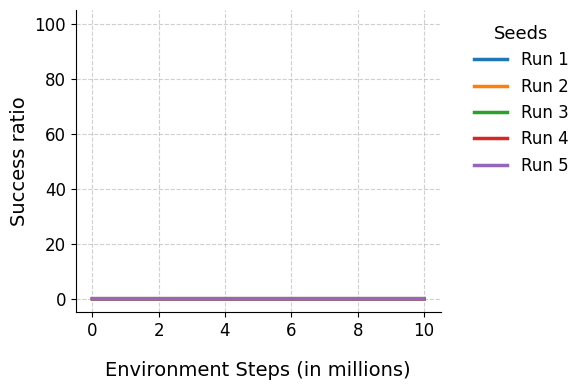

In [ ]:
# ==========================================
# DATENVERARBEITUNG
# ==========================================
# A) Nur die gewünschte Metrik aus ALLEN Runs herausfiltern
df_plot = df_all_runs[df_all_runs['tag'] == TARGET_TAG].copy()
df_plot = df_plot.sort_values(by='step')

# HIER IST DER SAUBERE TRICK:
# Wir erstellen ein Mapping von den alten Ordnernamen (sortiert) zu "Run 1", "Run 2", ...
unique_runs = sorted(df_plot['dir_name'].unique())
run_mapping = {old_name: f"Run {i+1}" for i, old_name in enumerate(unique_runs)}

# Jetzt benennen wir die Spalte im DataFrame um
df_plot['dir_name'] = df_plot['dir_name'].map(run_mapping)

# B) Glätten (Jeden Run einzeln glätten über groupby)
df_plot['smoothed_value'] = df_plot.groupby('dir_name')['value'].transform(
    lambda x: x.rolling(SMOOTHING_WINDOW, min_periods=1).mean()
)
df_plot = df_plot.dropna(subset=['smoothed_value'])

# C) Normalisierung anwenden
if NORMALIZE:
    df_plot['smoothed_value'] = df_plot['smoothed_value'] * 100

# ==========================================
# PLOTTEN
# ==========================================
plt.figure(figsize=(6, 4))

# HIER IST DER FIX: Eine Liste mit der exakten Reihenfolge erstellen
legend_order = [f"Run {i+1}" for i in range(len(unique_runs))]

# Und mit hue_order=legend_order an Seaborn übergeben
sns.lineplot(
    data=df_plot, 
    x='step', 
    y='smoothed_value', 
    hue='dir_name', 
    hue_order=legend_order,  # <-- ZWINGT DIE REIHENFOLGE AUF 1, 2, 3...
    linewidth=2.5  
)

# ==========================================
# STYLING
# ==========================================
plt.xlabel("Environment Steps (in millions)", fontsize=14, labelpad=15)

if NORMALIZE:
    plt.ylabel(f"{Y_AXIS_LABEL} (%)", fontsize=14)
else:
    plt.ylabel(Y_AXIS_LABEL, fontsize=14)

plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1e6:g}'))

if ENFORCE_BOUNDS:
    plt.ylim(bottom=Y_MIN, top=Y_MAX)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine() 
plt.grid(True, linestyle='--', alpha=0.6)

# Jetzt können wir die Legende ganz normal außerhalb platzieren, ohne dass sie kaputtgeht
plt.legend(
    title="Seeds", 
    title_fontsize=13, 
    fontsize=12,       
    frameon=False, 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left'          
)

plt.tight_layout()
# plt.savefig("all_runs_single_metric.pdf", format="pdf", bbox_inches="tight")
plt.show()